<a href="https://colab.research.google.com/github/DariaLaska/ml/blob/main/%D0%A6%D0%B2%D0%B5%D1%82%D0%BE%D1%87%D0%BA%D0%B8_vgg19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from tensorflow.keras.models import Model # Импортируем модели keras: Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, concatenate, Activation, MaxPooling2D, Conv2D, BatchNormalization, Flatten, Dense, Dropout, Conv2DTranspose, Concatenate, Reshape
from tensorflow.keras.optimizers import Adam # Импортируем оптимизатор Adam
from tensorflow.keras import callbacks
from tensorflow.keras import utils # Импортируем модуль utils библиотеки tensorflow.keras для получения OHE-представления
from google.colab import files # Импортируем Модуль files для работы с файлами
import matplotlib.pyplot as plt # Импортируем модуль pyplot библиотеки matplotlib для построения графиков
from tensorflow.keras.preprocessing import image # Импортируем модуль image для работы с изображениями
import numpy as np # Импортируем библиотеку numpy
from sklearn.model_selection import train_test_split
import time
import random
import math
import os # Импортируем библиотеку os для раоты с фаловой системой
from PIL import Image # импортируем модель Image для работы с изображениями
from google.colab import drive
import datetime

In [ ]:
# Библиотеки PyTorch
import torch
import torchvision # Датасеты и готовые модели
import torch.nn as nn # Готовые слои
import torch.utils.data as data # Работа с данными
import torchvision.transforms as transforms
import torchvision.datasets as dsets # Работа с датасетами
# from torch.autograd import Variable # Автоматический дифференциатор

In [ ]:
import random
import os

In [ ]:
dataset = '/content/drive/MyDrive/Colab Notebooks/ML/2 семестр/ml/flowers.zip'
db      = '/content/flowers'

In [ ]:
!ls "/content/drive/MyDrive/Colab Notebooks/ML/2 семестр/ml/"

 flowers.zip
 hh_salary.zip
'KT 2'
 KT3.ipynb
 three_spickers.wav
 Занятие_1_ml
'звук - классификация музыкальных жанров '
'Копия блокнота " IThub - ML3 - PyTorch - VGG16"'
'Копия блокнота "IThub - ML3 - PyTorch - введение"'
'Копия блокнота "IThub - ML3 - PyTorch - нейросеть на датасете CIFAR"'
'Копия блокнота " IThub - ML3 - PyTorch - перенос стиля с использованием VGG19"'
'Копия блокнота "IThub - ML3 - Генетические алгоритмы"'
'Копия блокнота "ITHub - ML3 - звук - speech_recognition"'
'Копия блокнота " ITHub - ML3 - звук - Yandex Speechkit"'
'Копия блокнота "ITHub - ML3 - звук - обработка с pyDub"'
'Копия блокнота "IThub - кластеризация голосов для идентификации спикеров"'
'КТ 1'
 Цветочки
'Цветочки vgg19'


In [ ]:
!unzip "/content/drive/MyDrive/Colab Notebooks/ML/2 семестр/ml/flowers.zip" -d "/content/flowers"

Archive:  /content/drive/MyDrive/Colab Notebooks/ML/2 семестр/ml/flowers.zip
  inflating: /content/flowers/flowers/daisy/100080576_f52e8ee070_n.jpg  
  inflating: /content/flowers/flowers/daisy/10140303196_b88d3d6cec.jpg  
  inflating: /content/flowers/flowers/daisy/10172379554_b296050f82_n.jpg  
  inflating: /content/flowers/flowers/daisy/10172567486_2748826a8b.jpg  
  inflating: /content/flowers/flowers/daisy/10172636503_21bededa75_n.jpg  
  inflating: /content/flowers/flowers/daisy/102841525_bd6628ae3c.jpg  
  inflating: /content/flowers/flowers/daisy/10300722094_28fa978807_n.jpg  
  inflating: /content/flowers/flowers/daisy/1031799732_e7f4008c03.jpg  
  inflating: /content/flowers/flowers/daisy/10391248763_1d16681106_n.jpg  
  inflating: /content/flowers/flowers/daisy/10437754174_22ec990b77_m.jpg  
  inflating: /content/flowers/flowers/daisy/10437770546_8bb6f7bdd3_m.jpg  
  inflating: /content/flowers/flowers/daisy/10437929963_bc13eebe0c.jpg  
  inflating: /content/flowers/flowers/

In [ ]:
labels = {} # Используем словарь
labels['daisy']     = [1,0,0,0,0]
labels['dandelion'] = [0,1,0,0,0]
labels['rose']      = [0,0,1,0,0]
labels['sunflower'] = [0,0,0,1,0]
labels['tulip'] =     [0,0,0,0,1]

In [ ]:
# Вычисление пропорций для изменения размера
def smart_resize(img, target):
  base_width = img.width
  base_height = img.height
  target_width = target[0]
  target_height = target[1]

  width_first_way = round(target_height / base_height * base_width)

  if width_first_way < target_width:
    height_first_way = round(target_width / base_width * base_height)
    img = img.resize((target_width, height_first_way))
  else:
    img = img.resize((width_first_way, target_height))

  left = (img.width - target_width) // 2
  top = (img.height - target_height) // 2
  right = left + target_width
  bottom = top + target_height
  img = img.crop((left, top, right, bottom))

  return img

In [ ]:
image_list = []

for label in labels.keys():
  dir = db+"/flowers/" + label
  flist = os.listdir(db+"/flowers/" + label)
  c = 0
  for f in flist:
    fpath = db+"/flowers/" + label + "/" + f
    image_list.append(fpath)

random.shuffle(image_list)


x_train = []
y_train = []
for fpath in image_list:
  img = Image.open(fpath)
  img = smart_resize(img, (80,80))

  image_data = np.array(img)
  x_train.append(image_data)

  label = fpath.split('/')[4]
  y_train.append(labels[label])

x_train = np.array(x_train)
y_train = np.array(y_train)
print(x_train.shape)
print(y_train.shape)

(4317, 80, 80, 3)
(4317, 5)


In [ ]:
import os
import random
import numpy as np
from PIL import Image

# Предполагаем, что labels и smart_resize уже определены

image_list = []
for label in labels.keys():
    dir_path = os.path.join(db, "flowers", label)
    flist = os.listdir(dir_path)
    for f in flist:
        fpath = os.path.join(dir_path, f)
        image_list.append(fpath)

random.shuffle(image_list)

# Разделяем на обучающую и тестовую выборки (80%/20%)
split_idx = int(0.8 * len(image_list))
train_files = image_list[:split_idx]
test_files = image_list[split_idx:]

# Обработка обучающей выборки
x_train = []
y_train = []
for fpath in train_files:
    img = Image.open(fpath)
    img = smart_resize(img, (80, 80))
    image_data = np.array(img)
    x_train.append(image_data)
    label = fpath.split(os.sep)[-2]  # Берем папку как метку
    y_train.append(labels[label])

# Обработка тестовой выборки
x_test = []
y_test = []
for fpath in test_files:
    img = Image.open(fpath)
    img = smart_resize(img, (80, 80))
    image_data = np.array(img)
    x_test.append(image_data)
    label = fpath.split(os.sep)[-2]  # Берем папку как метку
    y_test.append(labels[label])

# Преобразуем в numpy массивы
x_train = np.array(x_train)
y_train = np.array(y_train)
x_test = np.array(x_test)
y_test = np.array(y_test)

print("Обучающая выборка:", x_train.shape, y_train.shape)
print("Тестовая выборка:", x_test.shape, y_test.shape)

Обучающая выборка: (3453, 80, 80, 3) (3453, 5)
Тестовая выборка: (864, 80, 80, 3) (864, 5)


array([[[108, 123, 145],
        [116, 132, 155],
        [124, 141, 167],
        ...,
        [130, 104,  79],
        [154, 140, 117],
        [ 86,  94, 110]],

       [[106, 123, 136],
        [114, 129, 148],
        [122, 138, 164],
        ...,
        [134, 116,  92],
        [116,  96,  79],
        [106, 111, 117]],

       [[101, 111, 126],
        [105, 118, 132],
        [119, 128, 142],
        ...,
        [149, 120,  86],
        [103, 109, 123],
        [ 97, 107, 127]],

       ...,

       [[128, 150, 174],
        [133, 156, 180],
        [131, 153, 177],
        ...,
        [ 87,  96,  89],
        [ 66,  62,  26],
        [ 81,  88,  91]],

       [[115, 135, 158],
        [112, 132, 152],
        [116, 136, 158],
        ...,
        [ 95,  96,  50],
        [122, 115,  29],
        [165, 181, 199]],

       [[138, 158, 183],
        [150, 167, 196],
        [144, 163, 190],
        ...,
        [111, 102,  25],
        [157, 143,  23],
        [143, 152, 153]]], dtype=uint8)
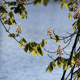

In [ ]:
x_test[0]
#y_test[0]

In [ ]:
y_test[0]

array([0, 0, 0, 0, 1])

#VGG

In [ ]:
# vgg19 = models.vgg19(pretrained=True)
vgg19 = torchvision.models.vgg19(weights=True).eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
vgg19

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [ ]:
batchSize = 100 # Размер батча
numClasses = 5 # Количество классов
numEpochs = 15  # Количество эпох
learningRate = 0.00001 # Шаг для оптимайзера

In [ ]:
# Задаем набор трансформаций с теми параметрами, которые были заданы при обучении модели
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Resize(size=224),
                                transforms.CenterCrop(size=224),
                                transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))])

#torch.Size([3, 224, 224])

In [ ]:
trainLoader = []
for i in range(len(x_test)):
    trans = transform(x_test[i])
    print(trans.shape)
    trainLoader.append(trans)

x_test[i].shape

torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([

(80, 80, 3)

In [ ]:
len(x_train )

3453

In [ ]:
x_train_tensor = torch.tensor(x_train, dtype=torch.float32).permute(0, 3, 1, 2)

print(x_train_tensor.shape)  # torch.Size([3453, 3, 80, 80])

torch.Size([3453, 3, 80, 80])


In [ ]:
(x_train_tensor.shape)

torch.Size([3453, 3, 80, 80])

In [ ]:
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

print(y_train_tensor.shape)  # torch.Size([3453, 5])

torch.Size([3453, 5])


In [ ]:
(y_train_tensor.shape)

torch.Size([3453, 5])

In [ ]:
for param in vgg19.parameters():
    param.requires_grad = False

In [ ]:
vgg19.classifier = nn.Sequential(
            nn.Linear(25088, 1024), #512 * 2 * 2
            nn.LayerNorm(1024),
            nn.ReLU(True),
            nn.Dropout(p=0.3, inplace=False),
            nn.Linear(1024, numClasses)
        )

In [ ]:
vgg19

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [ ]:
# Проверим, включен ли у нас GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
device

device(type='cuda')

In [ ]:
vgg19.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [ ]:
!pip install torchinfo

In [ ]:
from torchinfo import summary

summary(vgg19) #, input_size=(batch_size, 3, 32, 32))

Layer (type:depth-idx)                   Param #
VGG                                      --
├─Sequential: 1-1                        --
│    └─Conv2d: 2-1                       (1,792)
│    └─ReLU: 2-2                         --
│    └─Conv2d: 2-3                       (36,928)
│    └─ReLU: 2-4                         --
│    └─MaxPool2d: 2-5                    --
│    └─Conv2d: 2-6                       (73,856)
│    └─ReLU: 2-7                         --
│    └─Conv2d: 2-8                       (147,584)
│    └─ReLU: 2-9                         --
│    └─MaxPool2d: 2-10                   --
│    └─Conv2d: 2-11                      (295,168)
│    └─ReLU: 2-12                        --
│    └─Conv2d: 2-13                      (590,080)
│    └─ReLU: 2-14                        --
│    └─Conv2d: 2-15                      (590,080)
│    └─ReLU: 2-16                        --
│    └─Conv2d: 2-17                      (590,080)
│    └─ReLU: 2-18                        --
│    └─MaxPool2d: 2

In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset

# Преобразуем метки из one-hot в индексы классов
y_train_indices = torch.argmax(y_train_tensor, dim=1)

# Создаем TensorDataset и DataLoader
train_dataset = TensorDataset(x_train_tensor, y_train_indices)
train_loader = DataLoader(train_dataset, batch_size=batchSize, shuffle=True)

In [ ]:
# Возьмем нужную функцию ошибки
criterion = nn.CrossEntropyLoss()

# Выбираем оптимизатор Adam. Берем параметры только последнего слоя
optimizer = torch.optim.Adam(vgg19.classifier.parameters(), lr=learningRate)

# Обучение
for epoch in range(numEpochs):
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = vgg19(images)
        loss = criterion(outputs, labels)
        _, predicted = torch.max(outputs, 1)
        accuracy = (predicted == labels).to(float).mean()
        loss.backward()
        optimizer.step()

    print(f'Эпоха: [{epoch+1}/{numEpochs}], Батч: [{i+1}/{len(train_loader)}], Ошибка: {loss.item():.4f}, Точность: {accuracy.item():.4f}')

Эпоха: [1/15], Батч: [35/35], Ошибка: 0.9808, Точность: 0.6038
Эпоха: [2/15], Батч: [35/35], Ошибка: 0.8006, Точность: 0.7170
Эпоха: [3/15], Батч: [35/35], Ошибка: 0.7035, Точность: 0.7170
Эпоха: [4/15], Батч: [35/35], Ошибка: 0.4863, Точность: 0.8679
Эпоха: [5/15], Батч: [35/35], Ошибка: 0.7314, Точность: 0.7925
Эпоха: [6/15], Батч: [35/35], Ошибка: 0.4991, Точность: 0.8302
Эпоха: [7/15], Батч: [35/35], Ошибка: 0.5799, Точность: 0.7925
Эпоха: [8/15], Батч: [35/35], Ошибка: 0.5647, Точность: 0.8113
Эпоха: [9/15], Батч: [35/35], Ошибка: 0.3923, Точность: 0.8679
Эпоха: [10/15], Батч: [35/35], Ошибка: 0.3860, Точность: 0.9434
Эпоха: [11/15], Батч: [35/35], Ошибка: 0.3699, Точность: 0.9057
Эпоха: [12/15], Батч: [35/35], Ошибка: 0.3385, Точность: 0.9245
Эпоха: [13/15], Батч: [35/35], Ошибка: 0.3105, Точность: 0.9245
Эпоха: [14/15], Батч: [35/35], Ошибка: 0.2845, Точность: 0.9623
Эпоха: [15/15], Батч: [35/35], Ошибка: 0.1850, Точность: 1.0000


In [ ]:
torch.save(vgg19, 'our_vgg16.pkl')
vgg19 = torch.load('our_vgg16.pkl', weights_only=False)

In [ ]:
x_test_tensor = torch.tensor(x_test, dtype=torch.float32).permute(0, 3, 1, 2)
print(x_test_tensor.shape)  # torch.Size([3453, 3, 80, 80])

torch.Size([864, 3, 80, 80])


In [ ]:
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
print(y_test_tensor.shape)  # torch.Size([3453, 5])

torch.Size([864, 5])


In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset

# Преобразуем метки из one-hot в индексы классов
y_test_indices = torch.argmax(y_test_tensor, dim=1)

# Создаем TensorDataset и DataLoader
test_dataset = TensorDataset(x_test_tensor, y_test_indices)
test_loader = DataLoader(test_dataset, batch_size=batchSize, shuffle=True)

In [ ]:
curTime = time.time()
vgg19.to(device).eval()  # включаем режим предикта
correct = 0
total = 0

for images, labels in test_loader:  # проходимся по всему тестовому загрузчику
    images, labels = images.to(device), labels.to(device)
    with torch.no_grad():
        outputs = vgg19(images)  # предикт
    _, predicted = torch.max(outputs.data, 1)  # получаем максимальное значение и определяем индекс
    total += labels.size(0)  # здесь лежит общее количество
    correct += (predicted == labels).sum().item()  # сравниваем с метками из текущего батча

print('Точность для тестовой выборки: %f %%' % (100 * correct / total))
print('time: ', round(time.time()-curTime,2),' с',sep='')

Точность для тестовой выборки: 71.296296 %
time: 0.89 с


vgg 19

vgg 16

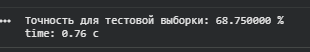

In [ ]:
print(img)

<PIL.Image.Image image mode=RGB size=80x80 at 0x7ACF196ACDA0>


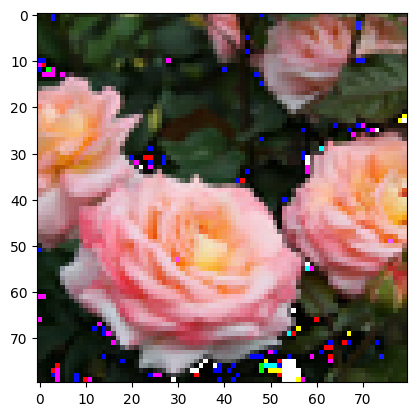

Предсказание сети: rose


In [ ]:
# Классы объектов в датасете CIFAR10
classes=['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

# Номер картинки
n = 1

# Переносим тензор на CPU и преобразуем в numpy
img_array = (images[n].cpu().numpy() * 255).astype(np.uint8)
# Переводим массив в изображение, изменяя размерность
img = np.transpose(img_array, (1, 2, 0))

# img = img.astype(np.uint8)
# # img = img[..., ::-1]

# Преобразуем массив в объект Pillow
x = Image.fromarray(255 - img).convert('RGB')

plt.imshow(x)
plt.show()

print("Предсказание сети:", classes[predicted[n].cpu().item()])

#+10 points

In [ ]:
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [ ]:
torchvision.models.vgg19(weights='DEFAULT')

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [ ]:
features = vgg19.features

class StyleNet(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.select = nn.Sequential(*list(features.children())[:27])  # до последнего MaxPool2d
        self.classifier = nn.Sequential(
            nn.Linear(512 * 10*10, 4096),  # 512*14*14 = 100352
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.select(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [ ]:
# class StyleNet(nn.Module):
#     def __init__(self):
#         super(StyleNet, self).__init__()
#         #self.select = [0, 5, 10, 19, 28] # слои (карты признаков), выходы которых будем использовать
#         # Берём все слои VGG19 до последнего MaxPool2d
#         self.select
#         self.features = nn.Sequential(*list(features.children())[:-1])
#         self.vgg19 = torchvision.models.vgg19(weights='DEFAULT').to(device) # загружаем сеть VGG19

#     def forward(self, x):
#         features = [] # Извлекаем по индексам, которые мы прописали выше, feature map из сетки
#         output = x
#         for layerIndex in range(len(self.vgg19.features)):
#           output = self.vgg19.features[layerIndex](output)
#           if layerIndex in self.select:
#             features.append(output)
#         return features

In [ ]:
model = StyleNet().eval()

In [ ]:
#optimizer = torch.optim.Adam([target], lr=0.05)

In [ ]:
contentCriteria = nn.MSELoss()

In [ ]:
# Проверим, включен ли у нас GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [ ]:
model.to(device)

StyleNet(
  (select): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), p

In [ ]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = StyleNet(num_classes=5).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# Обучение
for epoch in range(numEpochs):
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        _, predicted = torch.max(outputs, 1)
        accuracy = (predicted == labels).to(float).mean()
        loss.backward()
        optimizer.step()

    print(f'Эпоха: [{epoch+1}/{numEpochs}], Батч: [{i+1}/{len(train_loader)}], Ошибка: {loss.item():.4f}, Точность: {accuracy.item():.4f}')

Эпоха: [1/15], Батч: [35/35], Ошибка: 21.4622, Точность: 0.6604
Эпоха: [2/15], Батч: [35/35], Ошибка: 0.7512, Точность: 0.7736
Эпоха: [3/15], Батч: [35/35], Ошибка: 0.4338, Точность: 0.8302
Эпоха: [4/15], Батч: [35/35], Ошибка: 0.7067, Точность: 0.7736
Эпоха: [5/15], Батч: [35/35], Ошибка: 0.4304, Точность: 0.8868
Эпоха: [6/15], Батч: [35/35], Ошибка: 0.4404, Точность: 0.8302
Эпоха: [7/15], Батч: [35/35], Ошибка: 0.6760, Точность: 0.7547
Эпоха: [8/15], Батч: [35/35], Ошибка: 0.6548, Точность: 0.7925
Эпоха: [9/15], Батч: [35/35], Ошибка: 0.4681, Точность: 0.8679
Эпоха: [10/15], Батч: [35/35], Ошибка: 0.5379, Точность: 0.8491
Эпоха: [11/15], Батч: [35/35], Ошибка: 0.3822, Точность: 0.8679
Эпоха: [12/15], Батч: [35/35], Ошибка: 0.2311, Точность: 0.8868
Эпоха: [13/15], Батч: [35/35], Ошибка: 0.3838, Точность: 0.9434
Эпоха: [14/15], Батч: [35/35], Ошибка: 0.2566, Точность: 0.9057
Эпоха: [15/15], Батч: [35/35], Ошибка: 0.3839, Точность: 0.8491


In [ ]:
x_test_tensor = torch.tensor(x_test, dtype=torch.float32).permute(0, 3, 1, 2)
print(x_test_tensor.shape)  # torch.Size([3453, 3, 80, 80])

torch.Size([864, 3, 80, 80])


In [ ]:
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
print(y_test_tensor.shape)  # torch.Size([3453, 5])

torch.Size([864, 5])


In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset

# Преобразуем метки из one-hot в индексы классов
y_test_indices = torch.argmax(y_test_tensor, dim=1)

# Создаем TensorDataset и DataLoader
test_dataset = TensorDataset(x_test_tensor, y_test_indices)
test_loader = DataLoader(test_dataset, batch_size=batchSize, shuffle=True)

In [ ]:
curTime = time.time()
model.to(device).eval()  # включаем режим предикта
correct = 0
total = 0

for images, labels in test_loader:  # проходимся по всему тестовому загрузчику
    images, labels = images.to(device), labels.to(device)
    with torch.no_grad():
        outputs = vgg19(images)  # предикт
    _, predicted = torch.max(outputs.data, 1)  # получаем максимальное значение и определяем индекс
    total += labels.size(0)  # здесь лежит общее количество
    correct += (predicted == labels).sum().item()  # сравниваем с метками из текущего батча

print('Точность для тестовой выборки: %f %%' % (100 * correct / total))
print('time: ', round(time.time()-curTime,2),' с',sep='')

Точность для тестовой выборки: 70.138889 %
time: 0.89 с


vgg 19 без последнего блока

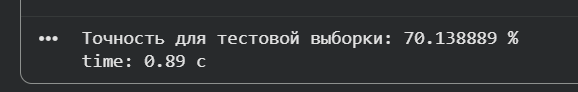